# Aproksymacja liniowa

***Zadanie 1.***

Zdefiniuj funkcję liniową z dowolnymi paramterami $a,b$. Przeprowadź symulację zaszumionego próbkowania jej wartości z przedziału [0,50]. Wykreśl funkcję wraz z jej zaszumionymi próbkami, a następnie dokonaj aproskymacji swojej funkcji za pomocą:
* funkcji liniowej,
* funkcji kwadratowej,
* wielomianu trzeciego stopnia.

Zastosuj metodę/metody minimalizujące najmniejszych kwadratów (normę średniokwadratową np. funkcję *curve_fit* z [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)).

Porównaj otrzymane wyniki z metodami interpolacji poznanymi na poprzednich zajęciach. W tym celu przeprowadź interpolację wygenerowanych danych za pomocą wielomianu interpolacyjnego Lagrange'a oraz za pomocą funkcji sklejanych.

*Wskazówka*: Najpierw wygerneruj tablicę 100 wartości $(x_i, f(x_i))$ dla $x_i \in [0,50]$. Następnie za pomocą np. funkcji *np.random.normal* wygeneruj 100-elementową tablicę szumu losowego i dodaj ją do wygenerowanych **wartości** funkcji (tj. do $f(x_i)$).

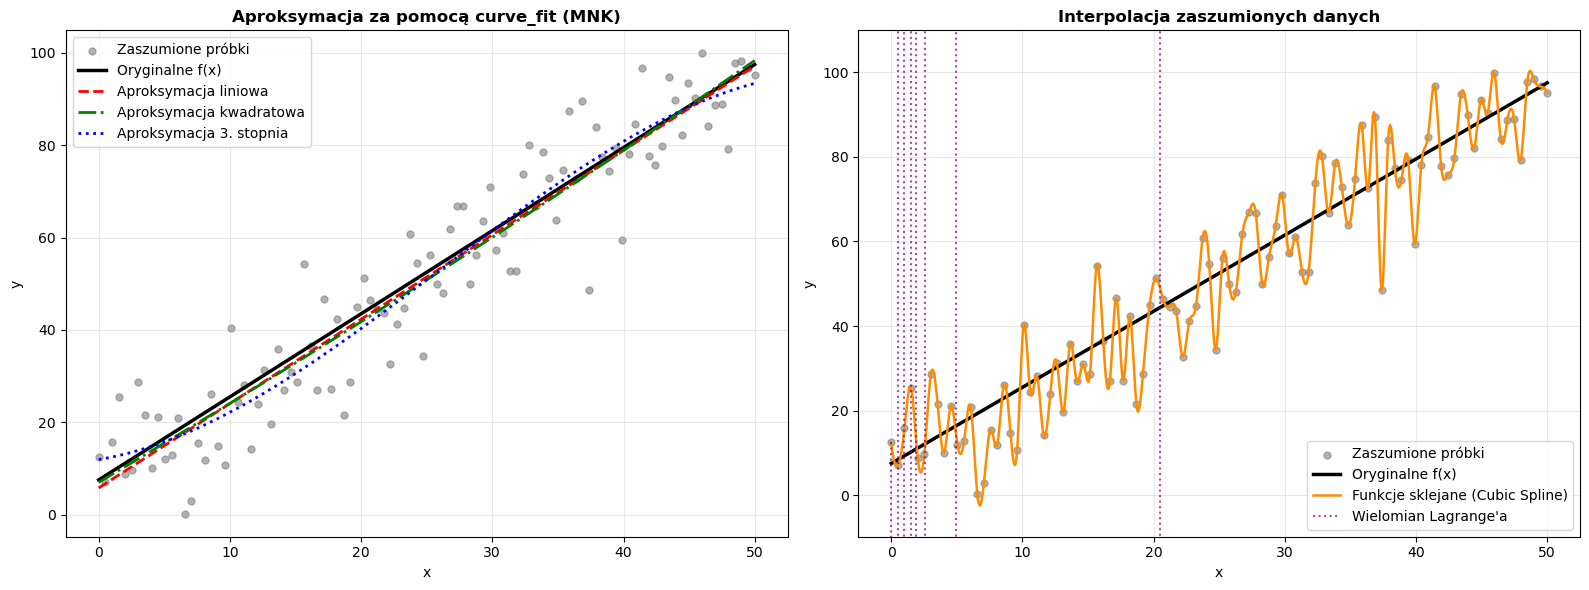

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, interp1d

def run_aproksymacja_zadanie():
    np.random.seed(42)
    a, b = 1.8, 7.5
    
    def f_czysta(x):
        return a * x + b

    x_nodes = np.linspace(0, 50, 100)
    y_pure = f_czysta(x_nodes)

    szum = np.random.normal(loc=0.0, scale=10.0, size=100)
    y_noisy = y_pure + szum

    def model_liniowy(x, a0, a1): 
        return a0 * x + a1
    def model_kwadratowy(x, a0, a1, a2): 
        return a0 * x**2 + a1 * x + a2
    def model_szescienny(x, a0, a1, a2, a3): 
        return a0 * x**3 + a1 * x**2 + a2 * x + a3

    popt_lin, _ = curve_fit(model_liniowy, x_nodes, y_noisy)
    popt_quad, _ = curve_fit(model_kwadratowy, x_nodes, y_noisy)
    popt_cub, _ = curve_fit(model_szescienny, x_nodes, y_noisy)

    f_spline = interp1d(x_nodes, y_noisy, kind='cubic')
    
    try:
        poly_lagrange = lagrange(x_nodes, y_noisy)
    except Exception as e:
        print(f"Problem z wielomianem Lagrange'a: {e}")
        poly_lagrange = None

    x_plot = np.linspace(0, 50, 1000)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.scatter(x_nodes, y_noisy, color='gray', alpha=0.6, s=25, label='Zaszumione próbki')
    ax1.plot(x_plot, f_czysta(x_plot), 'k-', linewidth=2.5, label='Oryginalne f(x)')
    ax1.plot(x_plot, model_liniowy(x_plot, *popt_lin), 'r--', linewidth=2, label='Aproksymacja liniowa')
    ax1.plot(x_plot, model_kwadratowy(x_plot, *popt_quad), 'g-.', linewidth=2, label='Aproksymacja kwadratowa')
    ax1.plot(x_plot, model_szescienny(x_plot, *popt_cub), 'b:', linewidth=2, label='Aproksymacja 3. stopnia')
    
    ax1.set_title("Aproksymacja za pomocą curve_fit (MNK)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.scatter(x_nodes, y_noisy, color='gray', alpha=0.6, s=25, label='Zaszumione próbki')
    ax2.plot(x_plot, f_czysta(x_plot), 'k-', linewidth=2.5, label='Oryginalne f(x)')
    ax2.plot(x_plot, f_spline(x_plot), 'darkorange', linewidth=1.8, label='Funkcje sklejane (Cubic Spline)')
    
    if poly_lagrange is not None:
  
        y_lagr_plot = poly_lagrange(x_plot)
        ax2.plot(x_plot, y_lagr_plot, 'purple', linestyle=':', alpha=0.7, label='Wielomian Lagrange\'a')
    
    ax2.set_ylim(min(y_noisy) - 10, max(y_noisy) + 10) 
    ax2.set_title("Interpolacja zaszumionych danych", fontsize=12, fontweight='bold')
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_aproksymacja_zadanie()

***Zadanie 2.***


Wykorzystaj metody aproksymacji do rozwiązania zadania z kierowcą z poprzednich ćwiczeń.


Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

Wyznaczona funkcja aproksymująca drogę s(t):
       2
-5.85 x + 48.35 x + 0.05

Czas minięcia fotoradaru (aproksymacja): t ≈ 2.267247 s
Prędkość przy fotoradarze: v ≈ 21.8232 m/s = 78.56 km/h


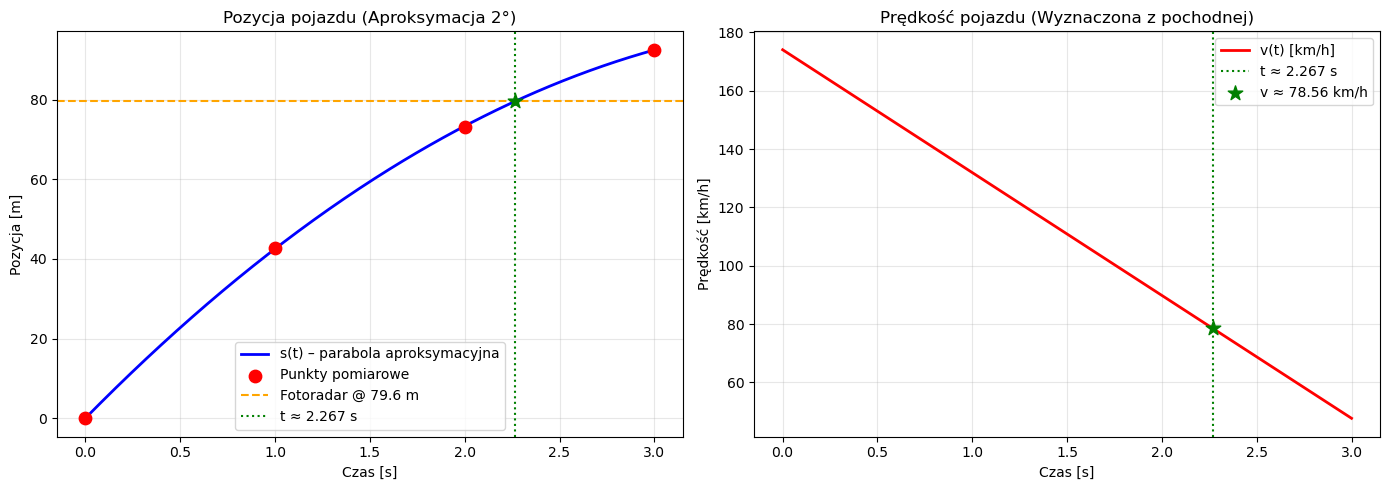

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def run_zadanie2_aproksymacja():
    t_data = np.array([0.0, 1.0, 2.0, 3.0])
    s_data = np.array([0.0, 42.7, 73.2, 92.5])
    radar_pos = 79.6  # [m]

    coefficients = np.polyfit(t_data, s_data, 2)
    poly_s = np.poly1d(coefficients)

    print("Wyznaczona funkcja aproksymująca drogę s(t):")
    print(poly_s)

    def equation(t):
        return poly_s(t) - radar_pos

    def bisection(f, a, b, tol=1e-10, max_iter=1000):
        if f(a) * f(b) >= 0:
            raise ValueError("Funkcja musi mieć różne znaki na krańcach przedziału.")
        for _ in range(max_iter):
            mid = (a + b) / 2
            if abs(f(mid)) < tol or (b - a) / 2 < tol:
                return mid
            if f(a) * f(mid) < 0:
                b = mid
            else:
                a = mid
        return (a + b) / 2

    t_a, t_b = 1.0, 3.0
    t_radar = bisection(equation, t_a, t_b)
    print(f"\nCzas minięcia fotoradaru (aproksymacja): t ≈ {t_radar:.6f} s")

    poly_v = np.polyder(poly_s)
    v_radar = poly_v(t_radar)
    print(f"Prędkość przy fotoradarze: v ≈ {v_radar:.4f} m/s = {v_radar * 3.6:.2f} km/h")

    t_plot = np.linspace(0, 3, 300)
    s_plot = poly_s(t_plot)
    v_plot = poly_v(t_plot)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(t_plot, s_plot, 'b-', linewidth=2, label='s(t) – parabola aproksymacyjna')
    axes[0].scatter(t_data, s_data, color='red', s=80, zorder=5, label='Punkty pomiarowe')
    axes[0].axhline(radar_pos, color='orange', linestyle='--', linewidth=1.5, label=f'Fotoradar @ {radar_pos} m')
    axes[0].axvline(t_radar, color='green', linestyle=':', linewidth=1.5, label=f't ≈ {t_radar:.3f} s')
    axes[0].scatter([t_radar], [radar_pos], color='green', s=120, zorder=6, marker='*')
    axes[0].set_title("Pozycja pojazdu (Aproksymacja 2°)")
    axes[0].set_xlabel("Czas [s]")
    axes[0].set_ylabel("Pozycja [m]")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_plot, v_plot * 3.6, 'r-', linewidth=2, label="v(t) [km/h]")
    axes[1].axvline(t_radar, color='green', linestyle=':', linewidth=1.5, label=f't ≈ {t_radar:.3f} s')
    axes[1].scatter([t_radar], [v_radar * 3.6], color='green', s=120, zorder=5, marker='*', label=f'v ≈ {v_radar*3.6:.2f} km/h')
    axes[1].set_title("Prędkość pojazdu (Wyznaczona z pochodnej)")
    axes[1].set_xlabel("Czas [s]")
    axes[1].set_ylabel("Prędkość [km/h]")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_zadanie2_aproksymacja()

***Zadanie 3.***


Spróbuj przeprowadzić regresję liniową (aproksymację funkcją liniową) na rzeczywistych danych (np. z repozytorium [UCI](https://archive.ics.uci.edu/ml/datasets.php?format=&task=reg&att=&area=&numAtt=&numIns=&type=&sort=nameUp&view=table)). Wykorzystaj stworzony model do predykcji. Dla ułatwienia możesz zastosować funkcję z biblioteki [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

Wyniki Modelu:
Równanie prostej regresji: y = 998.58 * x + 152.00
Błąd średniokwadratowy (MSE): 4061.83
Współczynnik determinacji (R^2): 0.2334

Predykcja dla nowego pacjenta (znormalizowane BMI = 0.1):
Przewidywany wskaźnik postępu choroby: 251.86


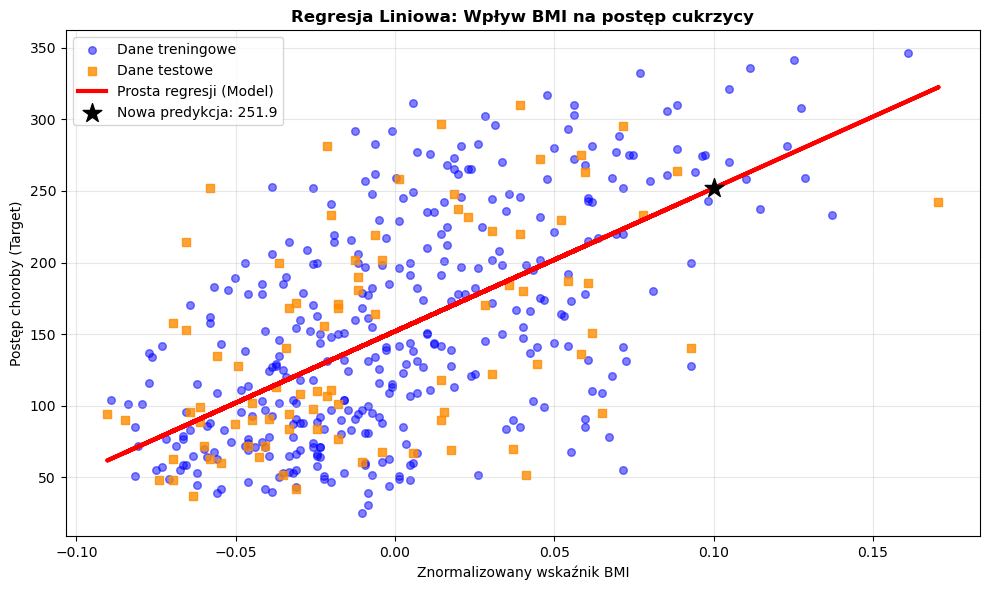

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def run_zadanie3_regresja():
    diabetes = load_diabetes()
    
    X = diabetes.data[:, np.newaxis, 2]
    y = diabetes.target

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    a = model.coef_[0]
    b = model.intercept_

    print("Wyniki Modelu:")
    print(f"Równanie prostej regresji: y = {a:.2f} * x + {b:.2f}")
    print(f"Błąd średniokwadratowy (MSE): {mean_squared_error(y_test, y_pred):.2f}")
    print(f"Współczynnik determinacji (R^2): {r2_score(y_test, y_pred):.4f}")

    custom_bmi = np.array([[0.1]])
    predicted_progression = model.predict(custom_bmi)
    print(f"\nPredykcja dla nowego pacjenta (znormalizowane BMI = 0.1):")
    print(f"Przewidywany wskaźnik postępu choroby: {predicted_progression[0]:.2f}")

    plt.figure(figsize=(10, 6))
    
    plt.scatter(X_train, y_train, color='blue', alpha=0.5, s=30, label='Dane treningowe')
    plt.scatter(X_test, y_test, color='darkorange', alpha=0.8, s=40, marker='s', label='Dane testowe')
    
    plt.plot(X_test, y_pred, color='red', linewidth=3, label='Prosta regresji (Model)')
    
    plt.scatter(custom_bmi, predicted_progression, color='black', marker='*', s=200, zorder=5, 
                label=f'Nowa predykcja: {predicted_progression[0]:.1f}')

    plt.title("Regresja Liniowa: Wpływ BMI na postęp cukrzycy", fontsize=12, fontweight='bold')
    plt.xlabel("Znormalizowany wskaźnik BMI")
    plt.ylabel("Postęp choroby (Target)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_zadanie3_regresja()